<a href="https://colab.research.google.com/github/worgen25/Notas-Bootcamp-Data-Analyst-2026/blob/main/Sprint_7_CH2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Concepto Principal
Este capítulo se enfoca en comparar grupos de datos y entender que la media no es suficiente para tomar decisiones. Aprendiste que dos grupos pueden tener el mismo promedio pero comportarse de manera completamente diferente.

Funciones Nuevas Utilizadas
Funciones de Pandas:

.mean()
Calcular la media
.min()
Encontrar el valor mínimo
.max()
Encontrar el valor máximo
.std()
Calcular la desviación estándar
Funciones de Matplotlib:

plt.hist()
Crear histogramas
plt.title()
Agregar título al gráfico
plt.xlabel()
Etiqueta del eje X
plt.ylabel()
Etiqueta del eje Y
plt.show()
Mostrar el gráfico


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos de ventas de diferentes tiendas
df_ventas = pd.read_csv('/datasets/ventas_tiendas.csv')

# creamos mini dataframes de cada tienda
tienda_a = df_ventas[df_ventas['tienda'] == 'Tienda A']
tienda_b = df_ventas[df_ventas['tienda'] == 'Tienda B']
tienda_c = df_ventas[df_ventas['tienda'] == 'Tienda C']

# Crear lista de dataframes para iterar
tiendas_lista = [tienda_a, tienda_b, tienda_c]
nombres_tiendas = ['Tienda A', 'Tienda B', 'Tienda C']

print("=== ANÁLISIS ESTADÍSTICO POR TIENDA ===")
print()

# Calcular métricas para cada tienda usando bucle for
for i, tienda in enumerate(tiendas_lista):
    print(f"--- {nombres_tiendas[i]} ---")
    print(f"Media de ventas: ${tienda['ventas_diarias'].mean():.2f}")
    print(f"Mínimo: ${tienda['ventas_diarias'].min():.2f}")
    print(f"Máximo: ${tienda['ventas_diarias'].max():.2f}")
    print(f"Desviación estándar: ${tienda['ventas_diarias'].std():.2f}")
    print()

# Crear histogramas para visualizar distribuciones
for i, tienda in enumerate(tiendas_lista):
    plt.hist(tienda['ventas_diarias'], bins=15, color='lightgreen', edgecolor='black')

    # Personalizar gráfico
    plt.title(f'Distribución de Ventas Diarias: {nombres_tiendas[i]}')
    plt.xlabel('Ventas Diarias ($)')
    plt.ylabel('Frecuencia')
    plt.show()

# Análisis de conclusiones
print("=== CONCLUSIONES ===")
print("Aunque las tres tiendas tengan ventas promedio similares,")
print("la distribución nos revela patrones diferentes:")
print("- Tienda con menor variabilidad = más predecible")
print("- Tienda con mayor variabilidad = más riesgo pero posible mayor potencial")

### 1. .describe() para columnas categóricas
- Propósito: Resumen rápido de columnas de texto
- Información que proporciona:
  - count: cantidad total de valores
  - unique: número de categorías únicas
  - top: categoría más frecuente
  - freq: frecuencia de la categoría más común

### 2. .value_counts()
- Propósito: Conocer todas las categorías y sus frecuencias
- Parámetros útiles:
  - normalize=True: para obtener frecuencias relativas (porcentajes)
  - dropna=False: para incluir valores nulos en el conteo

In [ ]:
import pandas as pd

# Cargar datos limpios
df = pd.read_csv('/datasets/everpeak_clean.csv')

# 1. Resumen rápido de columnas categóricas
print("=== RESUMEN RÁPIDO CON .describe() ===")
columnas_categoricas = ['product_category', 'city', 'state', 'payment_method']

for col in columnas_categoricas:
    print(f"\nColumna: {col}")
    print(df[col].describe())

# 2. Análisis detallado con .value_counts()
print("\n=== ANÁLISIS DETALLADO CON .value_counts() ===")

# Frecuencias absolutas
print("\nCategorías de productos (frecuencia absoluta):")
print(df['product_category'].value_counts())

# Frecuencias relativas (porcentajes)
print("\nCategorías de productos (porcentajes):")
print(df['product_category'].value_counts(normalize=True) * 100)

# Análisis de ciudades
print("\nTop 10 ciudades con más clientes:")
print(df['city'].value_counts().head(10))

# Métodos de pago
print("\nDistribución de métodos de pago:")
print(df['payment_method'].value_counts(normalize=True))

# 3. Detectar categorías raras
print("\n=== DETECTAR CATEGORÍAS POCO REPRESENTADAS ===")
city_counts = df['city'].value_counts()
ciudades_raras = city_counts[city_counts < 5]
print(f"Ciudades con menos de 5 clientes: {len(ciudades_raras)}")
print(ciudades_raras)

#¿Qué son los Histogramas?

Los histogramas te permiten pasar de solo mirar números a interpretar patrones visuales en tus datos.

Términos Importantes:

Bins: Los intervalos que dividen los datos en grupos para crear las barras del histograma
Range: El rango del eje X que enfoca la parte relevante de los datos
Sesgo: Mide qué tan asimétrica es una distribución
Right-skew: Cola hacia la derecha
Left-skew: Cola hacia la izquierda
Lo que Puedes Identificar con Histogramas
Patrones de Distribución:

Sesgo: Hacia dónde se extiende la cola de los datos
Dispersión: Cuán concentrados o dispersos están los valores
Valores atípicos: Valores que se alejan significativamente del resto

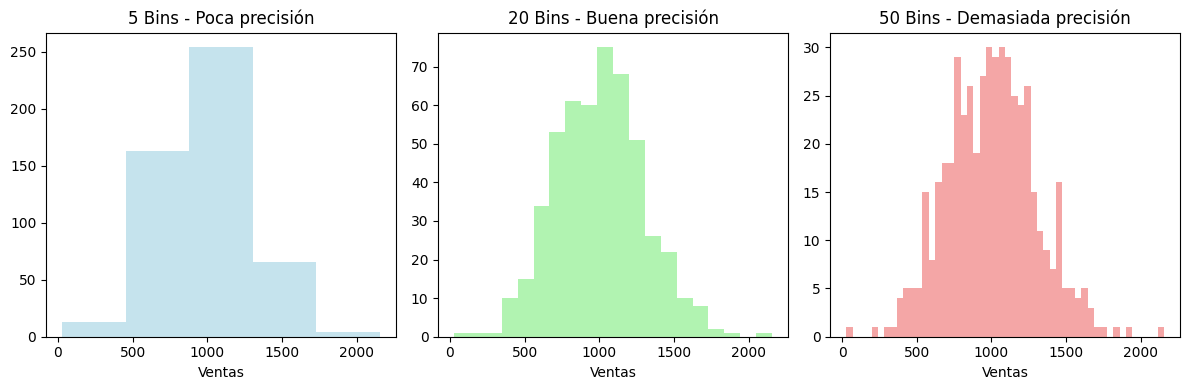

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Crear datos de ejemplo
np.random.seed(42)
ventas = np.random.normal(1000, 300, 500)  # Media 1000, desviación 300

# Crear histograma con diferentes números de bins
plt.figure(figsize=(12, 4))

# Pocos bins (5)
plt.subplot(1, 3, 1)
plt.hist(ventas, bins=5, color='lightblue', alpha=0.7)
plt.title('5 Bins - Poca precisión')
plt.xlabel('Ventas')

# Bins moderados (20)
plt.subplot(1, 3, 2)
plt.hist(ventas, bins=20, color='lightgreen', alpha=0.7)
plt.title('20 Bins - Buena precisión')
plt.xlabel('Ventas')

# Muchos bins (50)
plt.subplot(1, 3, 3)
plt.hist(ventas, bins=50, color='lightcoral', alpha=0.7)
plt.title('50 Bins - Demasiada precisión')
plt.xlabel('Ventas')

plt.tight_layout()
plt.show()

Los boxplots son herramientas visuales que te permiten analizar rápidamente una distribución de datos. Su función principal es:

1. Identificar outliers de forma inmediata
Los puntos fuera de los "bigotes" son valores atípicos
Te muestran qué tan extremos son estos valores
Es más directo que calcular estadísticas manualmente

2. Ver dónde se concentra la mayoría de los datos
La caja muestra el 50% central de tus datos
La mediana (línea dentro de la caja) te dice el valor típico
Los bigotes muestran el rango de valores "normales"
3. Medir la dispersión sin cálculos
Si la caja es estrecha → datos concentrados
Si la caja es ancha → datos más dispersos
El Rango Intercuartil (IQR) se ve visualmente
4. Comparar distribuciones entre grupos
Puedes poner varios boxplots lado a lado
Comparas medianas, dispersión y outliers fácilmente
5. Complementar a los histogramas
Los histogramas muestran la forma de la distribución
Los boxplots muestran outliers específicos y dispersión

Dataset generado:
Total de pedidos: 1000


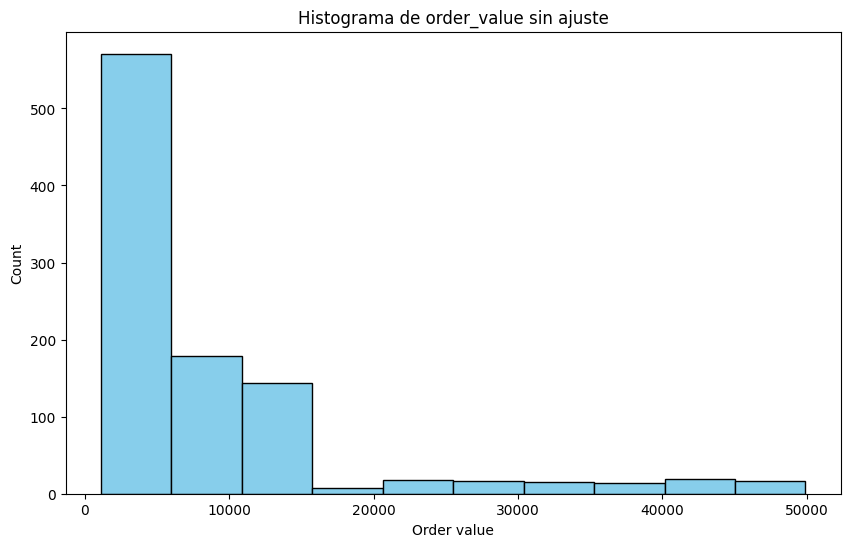


Observación: El eje X se estira por valores altos, dificultando ver patrones reales

Estadísticas descriptivas:
count     1000.000000
mean      9478.467520
std       9626.611293
min       1110.479192
25%       4526.736521
50%       5631.047446
75%      10862.647171
max      49913.735005
Name: order_value, dtype: float64

El 75% de los pedidos llega hasta: $10,862.65
Esto muestra un sesgo positivo hacia la derecha


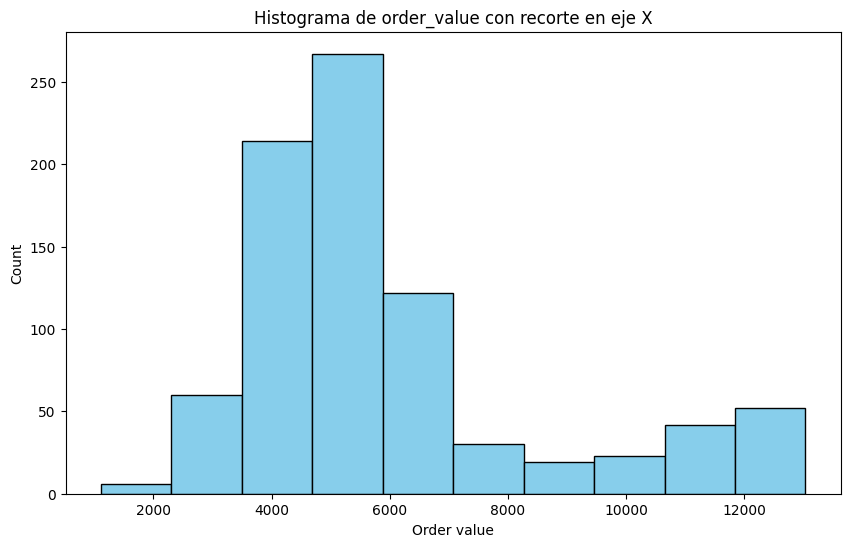

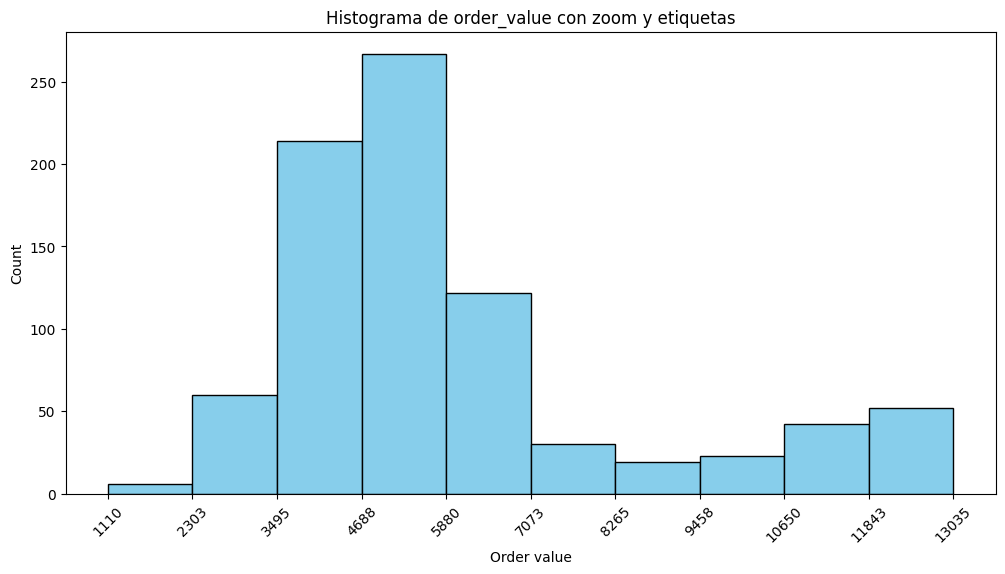

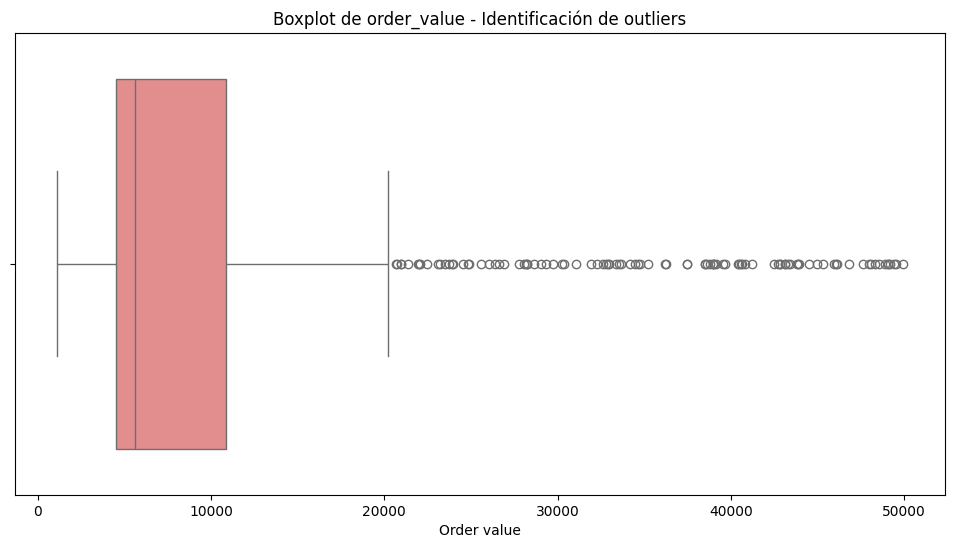

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===================================================================
# PASO 1: GENERAR BASE DE DATOS ALEATORIA
# ===================================================================

# Configuramos semilla para reproducibilidad
np.random.seed(42)

# Simulamos datos de pedidos de una tienda online
# Creamos una distribución realista con sesgo hacia la derecha
order_values = np.concatenate([
    np.random.normal(5000, 1200, 700),    # Pedidos típicos
    np.random.normal(12000, 2000, 200),   # Pedidos premium
    np.random.uniform(20000, 50000, 100)  # Pedidos excepcionales (outliers)
])

# Eliminamos valores negativos
order_values = order_values[order_values > 0]

# Creamos el DataFrame
df = pd.DataFrame({
    'order_value': order_values,
    'customer_id': range(len(order_values))
})

print("Dataset generado:")
print(f"Total de pedidos: {len(df)}")

# ===================================================================
# PASO 2: HISTOGRAMA BÁSICO (siguiendo la lección)
# ===================================================================

plt.figure(figsize=(10, 6))
plt.hist(df['order_value'], bins=10, color='skyblue', edgecolor='black')
plt.title('Histograma de order_value sin ajuste')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

print("\nObservación: El eje X se estira por valores altos, dificultando ver patrones reales")

# ===================================================================
# PASO 3: ANÁLISIS CON DESCRIBE() (como en la lección)
# ===================================================================

print("\nEstadísticas descriptivas:")
print(df['order_value'].describe())

# Identificamos el percentil 75% para ajustar el histograma
percentil_75 = df['order_value'].quantile(0.75)
valor_minimo = df['order_value'].min()

print(f"\nEl 75% de los pedidos llega hasta: ${percentil_75:,.2f}")
print("Esto muestra un sesgo positivo hacia la derecha")

# ===================================================================
# PASO 4: HISTOGRAMA CON RECORTE EN EJE X (siguiendo la lección)
# ===================================================================

# Usamos el mínimo y un poco por encima del 75%
limite_superior = percentil_75 * 1.2  # 20% por encima del 75%

plt.figure(figsize=(10, 6))
plt.hist(df['order_value'], bins=10, range=(valor_minimo, limite_superior),
         color='skyblue', edgecolor='black')
plt.title('Histograma de order_value con recorte en eje X')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

# ===================================================================
# PASO 5: HISTOGRAMA CON ETIQUETAS EN BORDES (como en la lección)
# ===================================================================

plt.figure(figsize=(12, 6))
counts, bin_edges, _ = plt.hist(df['order_value'], bins=10,
                                range=(valor_minimo, limite_superior),
                                color='skyblue', edgecolor='black')
plt.xticks(bin_edges, rotation=45)
plt.title('Histograma de order_value con zoom y etiquetas')
plt.xlabel('Order value')
plt.ylabel('Count')
plt.show()

# ===================================================================
# PASO 6: BOXPLOT PARA IDENTIFICAR OUTLIERS
# ===================================================================

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['order_value'], color='lightcoral')
plt.title('Boxplot de order_value - Identificación de outliers')
plt.xlabel('Order value')
plt.show()